In [2]:
!pip install -U langchain langchain-community langgraph langchain-groq duckduckgo-search

In [3]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage
from langgraph.prebuilt import ToolNode, tools_condition
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph.message import add_messages

In [4]:
class State(TypedDict):
    messages: Annotated[list, add_messages]

In [5]:
!pip install -U ddgs

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 kB 3.6 MB/s eta 0:00:00


In [6]:
from langchain_community.tools import DuckDuckGoSearchRun
search = DuckDuckGoSearchRun()
search.invoke("Obama's first name?")

/tmp/ipykernel_7484/2458726709.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools import DuckDuckGoSearchRun


'8 hours ago - Obama was also a member of the ... a self-named group of friends who spent time together and smoked marijuana. After graduating from high school in 1979, Obama moved to Los Angeles to attend Occidental College on a full scholarship. In February 1981, Obama made his first public speech, ... 1 week ago - Barack Hussein Obama II was born on August 4, 1961 in Kapiʻolani Medical Center for Women and Children (called Kapiʻolani Maternity & Gynecological Hospital in 1961) in Honolulu, Hawaii. He is the first President to have been born in Hawaii. His father was a black exchange student from Kenya named ... July 9, 2026 - Obama is a surname. It most commonly refers to Barack Obama (born 1961), the 44th president of the United States. Obama is a common Fang masculine name in western Central Africa. August 8, 2026 - Baker subsequently married a Tanzanian man named Ndesandjo and took his surname, as did her sons Mark and David. Mark said in 2009 that Obama had been abusive to him, 

In [7]:
search.invoke("What is AI?")

'The English sentence "What is your favorite AI chatbot?" translates to Portuguese (Portugal) as "Qual é o seu chatbot de IA favorito?" (formal/neutral) or informally "Qual é o teu chatbot de IA favorito?". This is a common question posed to AI cha… What is artificial intelligence? Artificial intelligence (AI) is the theory and development of computer systems capable of performing tasks that historically required human intelligence, such as recognizing speech, making decisions, and identifying patterns. What is Artificial Intelligence (AI)? AI is a technology that processes information, learns from patterns, and predicts outcomes to assist with tasks like answering questions, generating text, creating images and coding. Unlike traditional software, which follows exact instructions, AI adapts by analyzing data and identifying trends. What is AI? Get a simple, clear definition of artificial intelligence. This guide explains it for absolute beginners, showing how it works, its types, and 

In [8]:
search.invoke("What happened in the AI industry this week?")

"Dominant theme Tools & capabilities — 48 of 296 tracked stories this week ... The Editor's Blog All posts → OpenAI's agents browsed US government websites on their own Stanford: Agent Teams Beat a Perfect Oracle Router by 13.4 Points on AIME 2026 Paychex WISE Agentic Engine Now Serves 840,000 Customers 16B World Model Trained on 1.5M Object-Permanence Clips Ranks First in Continuation Category AI Magazine takes a look at some of the biggest stories from the past week, featuring the OpenAI-Australia incident and Musk's SpaceXAI prediction… 3 days ago - Meta’s muse is a mega hit, while Jev has everyone jabbering. Plus: Another OpenAI agent goes where it shouldn’t, a staggering $10 trillion infrastructure bet, and AI makes the Trump-Xi agenda 2 days ago - Seven days after the industry debated ... with total clarity: “Pacing” translated into two premier laboratories slashing prices by 50% within ninety minutes of each other.... 1 day ago - Warp announced a total $85M raised including a $6

In [9]:
search.invoke("Who is Elon Mus")

"7 hours ago - Elon Reeve Musk was born on June 28, 1971, in Pretoria, South Africa's administrative capital. He is of British and Pennsylvania Dutch ancestry. His mother, Maye (née Haldeman), is a model and dietitian born in Saskatchewan, Canada, and raised in South Africa. 5 days ago - Elon Reeve Musk FRS (born June 28, 1971) is a South African-Canadian-American businessman and entrepreneur. He moved to Canada and later became a U.S. citizen. He was the Commissioner of the Department of Government Efficiency for a few months in 2025 during the second Donald Trump administration. 2 weeks ago - Elon Musk is a businessman and entrepreneur known predominantly for his leading roles in the automotive company Tesla, Inc. and the space company SpaceX. Musk is also known for his ownership of technology company X Corp. 3 days ago - Elon Musk, the SpaceX and Tesla chief executive who rode their soaring valuations to become the world’s first trillionaire this year is seeing his $40 trillion U.S.

In [10]:
from langchain_community.tools import DuckDuckGoSearchRun

def search_duckduckgo(query: str):
    """Searches DuckDuckGo using LangChain's DuckDuckGoSearchRun tool."""
    search = DuckDuckGoSearchRun()
    return search.invoke(query)

# Example usage
result = search_duckduckgo("what are AI agent")
print(result)

11 hours ago - Layer 6: Security and compliance – a protective framework for safe operation and compliance with regulatory boundaries. At this layer, security and compliance features embedded into all the AI agent stack layers are integrated together. 5 days ago - In artificial intelligence, a ... as agentic AI) expand this concept by proactively pursuing goals, making decisions, and taking actions over extended periods. Intelligent agents operate based on an objective function, which encapsulates their goals. They are designed to create ... 3 weeks ago - An artificial intelligence (AI) agent refers to a system or program that is capable of autonomously performing tasks on behalf of a user or another system. 2 days ago - What is AI agents how and why businesses use AI agents, and how to use AI agents with AWS. February 23, 2026 - Today, attention has shifted to the next evolution of generative AI: AI agents or agentic AI, a new breed of AI systems that are semi- or fully autonomous and

In [11]:
def multiply(a:int,b:int) -> int:
    """
    Multiply a and b
    """
    return a* b

def add(a:int,b:int) -> int:
    """
    Adds a and b
    """
    return a + b

In [14]:
import os
from getpass import getpass

if not os.getenv("GROQ_API_KEY"):
    os.environ["GROQ_API_KEY"] = getpass("prajwal_api_key")

llm = ChatGroq(
    model="openai/gpt-oss-120b",
    temperature=0,
    api_key=os.environ["GROQ_API_KEY"]
)

In [15]:
llm.invoke('hello').content

'Hello! How can I help you today?'

In [16]:
tools = [search_duckduckgo, add, multiply]
llm_with_tools = llm.bind_tools(tools)

In [17]:
def chatbot(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

In [18]:
from langgraph.prebuilt import ToolNode, tools_condition

graph_builder = StateGraph(State)

# Define nodes
graph_builder.add_node("assistant",chatbot)
graph_builder.add_node("tools",ToolNode(tools))

#define edges
graph_builder.add_edge(START,"assistant")
graph_builder.add_conditional_edges("assistant",tools_condition)
graph_builder.add_edge("tools","assistant")

react_graph=graph_builder.compile()

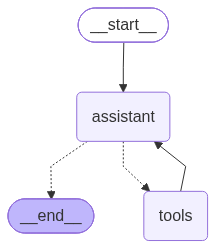

In [19]:
# To see the graph’s connection visually

display(Image(react_graph.get_graph().draw_mermaid_png()))

In [20]:
response = react_graph.invoke({"messages": [HumanMessage(content="what is the weather in delhi. Multiply it by 2 and add 5.")]})
print(response["messages"])

[HumanMessage(content='what is the weather in delhi. Multiply it by 2 and add 5.', additional_kwargs={}, response_metadata={}, id='29f8b2fc-f96b-4ad1-bb77-f6e9ee2d69d0'), AIMessage(content='', additional_kwargs={'reasoning_content': 'The user asks: "what is the weather in delhi. Multiply it by 2 and add 5."\n\nWe need to interpret: They want the current temperature (likely in degrees Celsius) in Delhi, then multiply that number by 2 and add 5, and give the result.\n\nWe need to fetch the weather. Use search tool to get current temperature. Use DuckDuckGo search query "Delhi weather temperature". Then parse result. Then compute: (temp * 2) + 5.\n\nWe need to be careful: The temperature may be in Celsius or Fahrenheit. Usually Indian weather sites give Celsius. We\'ll assume Celsius. We\'ll note the unit.\n\nWe\'ll fetch.', 'tool_calls': [{'id': 'fc_70c72601-6201-4a01-85f7-ea777fb93130', 'function': {'arguments': '{"query":"current temperature in Delhi"}', 'name': 'search_duckduckgo'}, '

In [21]:
response = react_graph.invoke({"messages":[HumanMessage(content="Who is the current CEO of NVIDIA?")]})
print(response["messages"])

[HumanMessage(content='Who is the current CEO of NVIDIA?', additional_kwargs={}, response_metadata={}, id='0649f810-7fcb-4ece-b778-2f3785ccd634'), AIMessage(content='', additional_kwargs={'reasoning_content': 'We need to answer: current CEO of NVIDIA. As of 2026? Need up-to-date info. Likely Jensen Huang is still CEO. He co-founded NVIDIA and has been CEO since founding. As of 2024, still CEO. Likely still in 2026. Provide answer. Could verify via search. Use search tool.', 'tool_calls': [{'id': 'fc_a1a6e95f-34ce-4d94-b0d7-7869746c4f29', 'function': {'arguments': '{"query":"current CEO of NVIDIA 2026"}', 'name': 'search_duckduckgo'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 107, 'prompt_tokens': 185, 'total_tokens': 292, 'completion_time': 0.228092849, 'completion_tokens_details': {'reasoning_tokens': 71}, 'prompt_time': 0.008442119, 'prompt_tokens_details': None, 'queue_time': 0.173891886, 'total_time': 0.236534968}, 'model_name': 'openai/gpt-oss-

In [22]:
response = react_graph.invoke({
    "messages": [
        HumanMessage(content="Who is the current CEO of NVIDIA?")
    ]
})

print(response["messages"])

[HumanMessage(content='Who is the current CEO of NVIDIA?', additional_kwargs={}, response_metadata={}, id='f445d8d8-3972-4f2c-a6bd-f0d6e6427c7f'), AIMessage(content='', additional_kwargs={'reasoning_content': 'We need to answer: current CEO of NVIDIA. As of 2026? Need up-to-date info. Likely Jensen Huang is still CEO. He co-founded NVIDIA and has been CEO since founding. As of 2024, still CEO. Likely still in 2026. Provide answer. Could verify via search. Use search tool.', 'tool_calls': [{'id': 'fc_92363cf7-49d0-4fee-a0da-6c8ba4ff9a2e', 'function': {'arguments': '{"query":"current CEO of NVIDIA 2026"}', 'name': 'search_duckduckgo'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 107, 'prompt_tokens': 185, 'total_tokens': 292, 'completion_time': 0.226053471, 'completion_tokens_details': {'reasoning_tokens': 71}, 'prompt_time': 0.007736962, 'prompt_tokens_details': None, 'queue_time': 0.060654981, 'total_time': 0.233790433}, 'model_name': 'openai/gpt-oss-

In [23]:
response = react_graph.invoke({
    "messages": [
        HumanMessage(content="Who is the current CEO of NVIDIA?")
    ]
})

print(response["messages"][-1].content)

Jensen Huang (Jen‑Hsun “Jensen” Huang) is the current chief executive officer of NVIDIA. He co‑founded the company in 1993 and has served as its President and CEO ever since.
